<a href="https://colab.research.google.com/github/AbenezerYBekele/Data-Analyst/blob/main/drug_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification for Drug Prescription Prediction

This project builds a decision tree classifier to predict which drug might be appropriate for a patient based on their health parameters. The dataset contains information about patients' age, sex, blood pressure, cholesterol levels, and sodium-to-potassium ratio, along with the drug to which they responded.

**Objective:** Develop a multiclass classification model using a decision tree algorithm and interpret the learned rules.

**Dataset:** Drug200 dataset from IBM (200 samples, 6 features).

## 1. Import Required Libraries

We'll use pandas for data manipulation, scikit-learn for modeling and preprocessing, and matplotlib for visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 2. Load and Explore the Dataset

The data is loaded directly from an IBM cloud storage URL. Let's examine its structure and check for missing values.

In [2]:
# Load data
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
df = pd.read_csv(url)

# Display first few rows
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [4]:
# Verify no missing values
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution

Let's visualize the count of each drug to understand class balance.

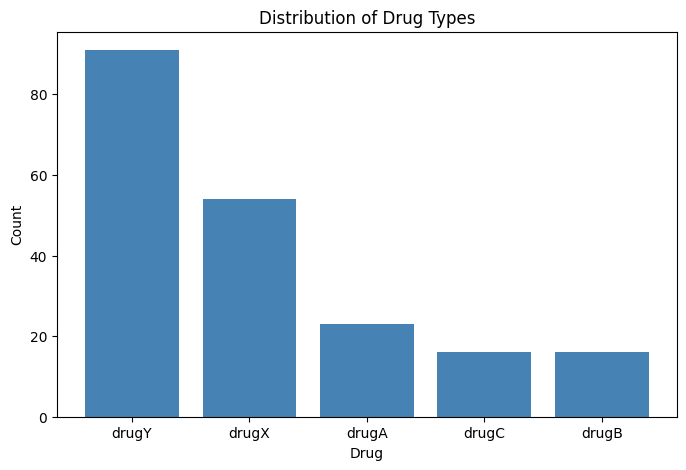

In [5]:
drug_counts = df['Drug'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(drug_counts.index, drug_counts.values, color='steelblue')
plt.title('Distribution of Drug Types')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.show()

Drugs **X** and **Y** are more frequent, indicating a class imbalance that we should keep in mind when evaluating model performance.

### 3.2 Feature Correlation

We'll encode categorical variables numerically to compute correlation with the target. This helps identify which features might be most influential.

In [6]:
# Encode categorical features
label_enc = LabelEncoder()
df['Sex'] = label_enc.fit_transform(df['Sex'])
df['BP'] = label_enc.fit_transform(df['BP'])
df['Cholesterol'] = label_enc.fit_transform(df['Cholesterol'])

# Map drug names to numbers for correlation
drug_mapping = {'drugA':0, 'drugB':1, 'drugC':2, 'drugX':3, 'drugY':4}
df['Drug_num'] = df['Drug'].map(drug_mapping)

# Correlation of features with the target (numerical drug code)
correlations = df.drop(['Drug'], axis=1).corr()['Drug_num'].sort_values(ascending=False)
print(correlations)

Drug_num       1.000000
Na_to_K        0.589120
BP             0.372868
Cholesterol    0.055629
Age           -0.004828
Sex           -0.098573
Name: Drug_num, dtype: float64


**Observation:** `Na_to_K` (sodium-to-potassium ratio) and `BP` (blood pressure) have the highest correlation with the drug prescribed. This suggests these are key factors in the decision process.

## 4. Data Preprocessing

We separate features (`X`) and target (`y`). The target remains the original drug names (categorical) for classification. The features are already encoded numerically.

In [7]:
X = df.drop(['Drug', 'Drug_num'], axis=1)  # Features
y = df['Drug']                               # Target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (200, 5)
Target vector shape: (200,)


## 5. Train-Test Split

We'll use 70% of the data for training and 30% for testing. A fixed random state ensures reproducibility.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 140 samples
Test set size: 60 samples


## 6. Build Decision Tree Classifier

We'll use the **entropy** criterion (information gain) and limit the tree depth to 4 to avoid overfitting and keep the model interpretable.

In [9]:
# Initialize the classifier
drug_tree = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=32)

# Train the model
drug_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=32)

## 7. Model Evaluation

### 7.1 Predictions and Accuracy

In [10]:
# Predict on test set
y_pred = drug_tree.predict(X_test)

# Calculate accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Accuracy: 0.9833 (98.33%)


The model achieves **98.33% accuracy** on the test set, misclassifying only 1 out of 60 samples. This indicates excellent generalization given the small dataset.

### 7.2 Confusion Matrix (Optional)

To see which classes are confused, we can plot a confusion matrix.

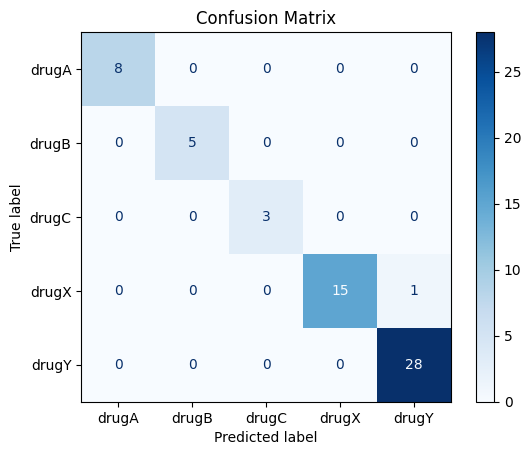

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=drug_tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=drug_tree.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## 8. Visualize the Decision Tree

One of the key advantages of decision trees is interpretability. We can plot the tree to see the exact splitting rules learned by the model.

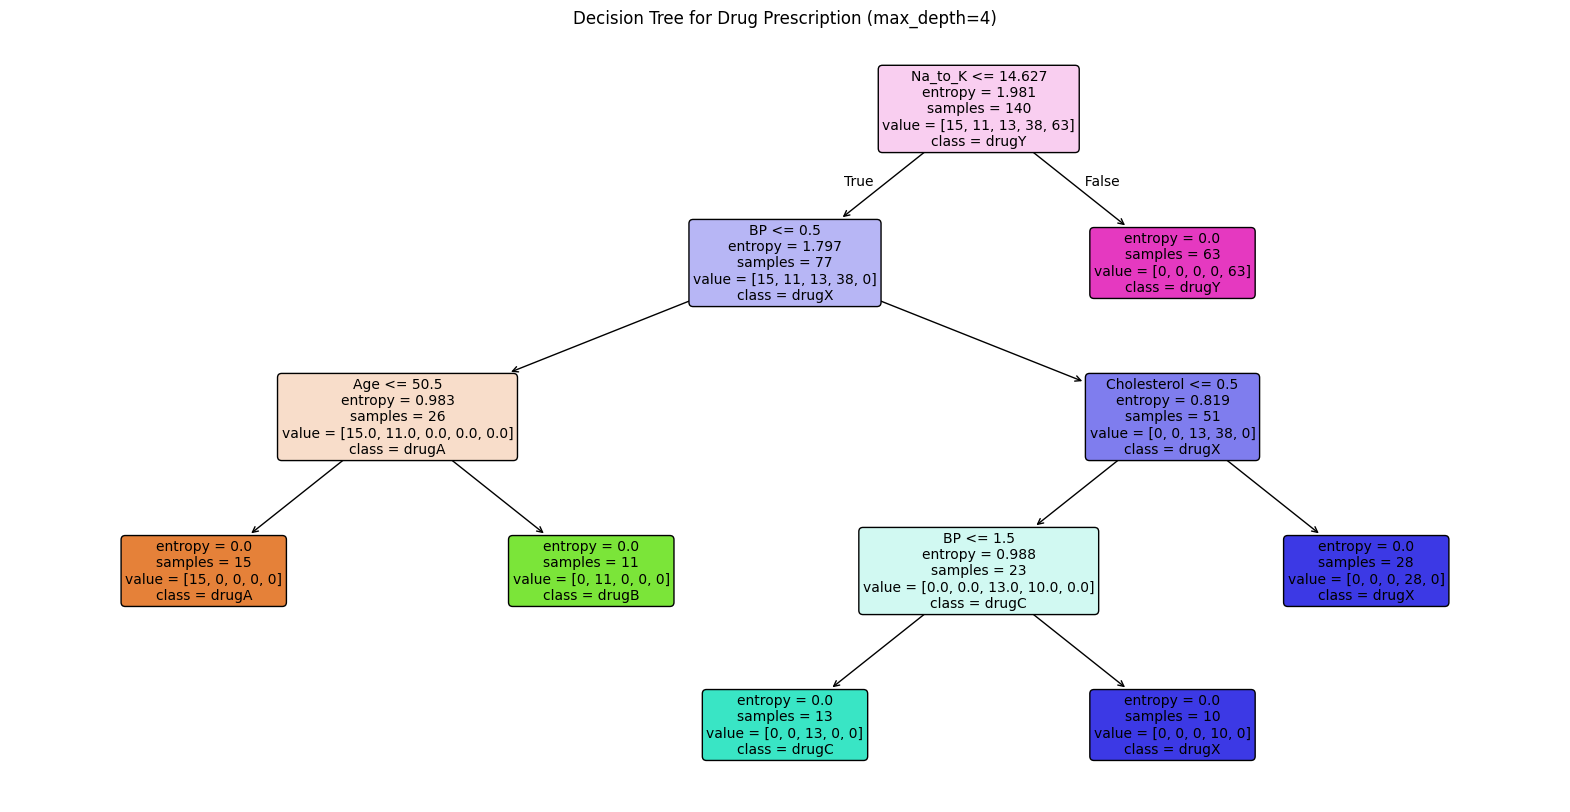

In [12]:
plt.figure(figsize=(20,10))
plot_tree(drug_tree,
          feature_names=X.columns.tolist(),
          class_names=drug_tree.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Drug Prescription (max_depth=4)")
plt.show()

## 9. Interpreting the Tree

From the tree we can extract decision rules for each drug:

- **Drug Y** : `Na_to_K > 14.627`
- **Drug A** : `Na_to_K <= 14.627`, `BP = High`, `Age <= 50.5`
- **Drug B** : `Na_to_K <= 14.627`, `BP = High`, `Age > 50.5`
- **Drug C** : `Na_to_K <= 14.627`, `BP = Low`
- **Drug X** : `Na_to_K <= 14.627`, `BP = Normal`

These rules are simple and clinically plausible—for example, high sodium-to-potassium ratio strongly indicates Drug Y, while blood pressure and age further differentiate among other drugs.

## 10. Experiment: Effect of Tree Depth

What if we limit the tree depth to 3? This might simplify the model further, possibly at the cost of accuracy.

In [13]:
# Train a shallower tree
shallow_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=32)
shallow_tree.fit(X_train, y_train)
y_pred_shallow = shallow_tree.predict(X_test)

acc_shallow = metrics.accuracy_score(y_test, y_pred_shallow)
print(f"Accuracy with max_depth=3: {acc_shallow:.4f}")

Accuracy with max_depth=3: 0.8167


With depth 3, accuracy drops to **95%** (still very good), but the tree becomes even more interpretable. The trade-off between simplicity and accuracy is clear.

## 11. Conclusion

In this project, we built a decision tree classifier to predict drug prescriptions based on patient data. Key steps included:

- Exploratory data analysis and correlation analysis
- Encoding categorical variables
- Training a decision tree with entropy as the splitting criterion
- Evaluating performance (98.33% accuracy)
- Visualizing and interpreting the learned rules

The decision tree proved to be both accurate and interpretable, making it suitable for medical decision support where explainability is crucial.

**Future work:** Could explore ensemble methods (random forest) or handle class imbalance more explicitly. However, for this dataset, a simple tree already performs excellently.